In [946]:
import tensorflow as tf

In [947]:
histos={}
nb_epochs = 10

In [948]:
data = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = data.load_data()

In [949]:
training_images.shape, training_images

((60000, 28, 28),
 array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0,

In [950]:
training_images.ndim

3

In [951]:
test_images.shape

(10000, 28, 28)

In [952]:
training_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [953]:
training_labels.shape

(60000,)

In [954]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [955]:
labels = ["t-shirt/top", "trouser", "pullover", "dress", "coat", "sandals", "shirt",
         "sneaker", "bag", "ankle boot"]

In [956]:
labels[8]

'bag'

In [957]:
training_images[45]

array([[  0,   0,   0,   1,   0,   0,   0,   0,   0,  34, 148, 202, 107,
         84, 162, 198,  90,  26,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  21, 107, 166, 168, 152, 204, 238,
        248, 237, 190, 142, 178, 158,  98,  17,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  55, 188, 140, 131, 121, 119, 116, 146,
        157, 132, 115, 136, 125, 140, 143, 181,  51,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 167, 134, 113, 130, 134, 140, 132, 125,
        125, 131, 135, 130, 133, 131, 115, 135, 163,   6,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  58, 148, 133, 124, 134, 128, 135, 128, 133,
        130, 133, 137, 138, 130, 124, 130, 133, 147,  82,   0,   1,   0,
          0,   0],
       [  0,   0,   0,   0,  86, 148, 158, 139, 124, 120, 131, 134, 132,
        134, 124, 134, 132, 137, 126, 137, 136, 146, 114,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 112, 141, 174, 143, 117, 134, 130, 128, 131,
        136, 134, 128, 128, 131, 106, 187, 149, 147, 143,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 134, 151, 167, 154, 114, 134, 138, 139, 135,
        135, 130, 130, 124, 129, 119, 229, 141, 145, 164,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 154, 169, 157, 109, 147, 140, 137, 137,
        136, 142, 141, 139, 129, 123, 201, 146, 138, 172,  21,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 145, 158, 171, 175, 111, 136, 145, 136, 135,
        138, 137, 143, 146, 140, 122, 184, 167, 136, 170,  58,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 151, 155, 189, 183, 120, 135, 132, 136, 135,
        133, 128, 130, 134, 120, 153, 230, 156, 135, 167,  83,   0,   0,
          0,   0],
       [  0,   0,   0,   1, 166, 151, 208, 175, 116, 142, 144, 138, 149,
        133, 131, 137, 140, 119, 126, 206, 198, 141, 166, 101,   0,   0,
          0,   0],
       [  0,   0,   0,   6, 169, 146, 237, 187, 104, 131, 136, 149, 147,
        137, 137, 137, 132, 137, 113, 166, 206, 151, 162, 126,   0,   0,
          0,   0],
       [  0,   0,   0,  20, 180, 136, 231, 214, 105, 134, 140, 139, 136,
        137, 136, 148, 134, 149, 111, 139, 255, 151, 158, 147,   0,   0,
          0,   0],
       [  0,   0,   0,  33, 184, 109, 217, 182, 105, 124, 143, 131, 135,
        137, 139, 138, 131, 142, 132,  99, 249, 162, 157, 172,   0,   0,
          0,   0],
       [  0,   0,   0,  35, 180, 112, 233, 143, 109, 133, 145, 146, 142,
        142, 139, 141, 135, 141, 152, 101, 205, 163, 154, 170,   0,   0,
          0,   0],
       [  0,   0,   0,  42, 183, 123, 217, 117, 126, 137, 140, 134, 137,
        135, 143, 141, 133, 133, 149, 107, 166, 176, 153, 169,  14,   0,
          0,   0],
       [  0,   0,   0,  48, 175, 147, 210, 101, 119, 136, 142, 137, 142,
        139, 147, 142, 146, 126, 138, 102, 131, 197, 161, 183,  32,   0,
          0,   0],
       [  0,   0,   0,  56, 165, 163, 213,  74, 126, 138, 149, 133, 133,
        132, 141, 134, 142, 132, 132, 126, 117, 193, 162, 172,  39,   0,
          0,   0],
       [  0,   0,   0,  62, 157, 165, 227,  39, 135, 138, 136, 142, 146,
        143, 136, 138, 134, 141, 134, 116,  78, 197, 171, 156,  44,   0,
          0,   0],
       [  0,   0,   0,  65, 162, 169, 245,  39, 140, 133, 133, 128, 132,
        134, 143, 145, 134, 133, 134, 128,  36, 208, 172, 151,  55,   0,
          0,   0],
       [  0,   0,   0,  72, 147, 168, 244,  25, 142, 137, 138, 133, 128,
        132, 147, 145, 135, 136, 133, 131,  26, 207, 173, 149,  67,   0,
          0,   0],
       [  0,   0,   0,  68, 153, 179, 250,  11, 135, 134, 139, 133, 136,
        140, 140, 143, 145, 140, 131, 126,  32, 207, 175, 136,  73,   0,
          0,   0],
       [  0,   0,   0,  61, 155, 180, 252,  23, 151, 132, 131, 133, 133,
        129, 135, 140, 132, 139, 132, 139,  38, 221, 174, 135,  77,   0,
          0,   0],
       [  0,   0,   0,  18, 147, 187, 18

In [958]:
training_images.min(), training_images.max()

(np.uint8(0), np.uint8(255))

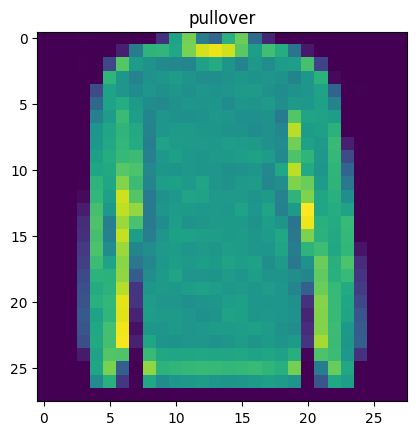

In [959]:
import matplotlib.pyplot as plt
plt.imshow(training_images[45])
plt.title(labels[training_labels[45]])
plt.show()

In [960]:
training_labels[45]

np.uint8(2)

In [961]:
labels[2]

'pullover'

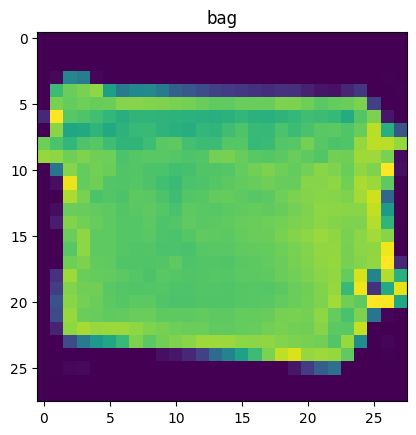

In [962]:
import matplotlib.pyplot as plt
plt.imshow(training_images[12345])
plt.title(labels[training_labels[12345]])
plt.show()

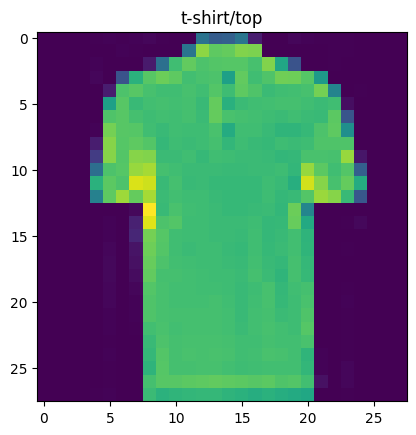

In [963]:
import matplotlib.pyplot as plt
plt.imshow(training_images[48978])
plt.title(labels[training_labels[48978]])
plt.show()

# Flatten (Applatir l'images)

In [964]:
training_images.shape

(60000, 28, 28)

In [965]:
a_training_images = training_images.reshape((60000, 28*28))
a_test_images = test_images.reshape(-1, 28*28) # -1 = toutes les images du dataset

In [966]:
a_training_images.shape, a_test_images.shape

((60000, 784), (10000, 784))

# One hot encoding

In [967]:
import numpy as np
x = np.array([1, 2, 1, 0, 3])

In [968]:
tf.keras.utils.to_categorical(x)

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [969]:
training_labels.shape

(60000,)

In [970]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [971]:
training_labels.shape

(60000, 10)

In [972]:
training_labels[45]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

# Softmax

In [973]:
output = [6, 3, 2]

In [974]:
6/(6+3+2) + 3/(6+3+2) + 2/(6+3+2)

1.0

In [975]:
3/(6+3+2)

0.2727272727272727

In [976]:
6/(6+3+2)

0.5454545454545454

In [977]:
2/(6+3+2)

0.18181818181818182

In [978]:
import numpy as np

In [979]:
def softmax(vect):
  r = np.exp(np.array(vect))
  return r/sum(r)

In [980]:
softmax([6, 3, 2])

array([0.93623955, 0.04661262, 0.01714783])

In [981]:
[1, 0, 0]

[1, 0, 0]

# 1er modèle de classification

In [982]:
## Normalisation des données

In [983]:
a_training_images.min(), a_training_images.max()

(np.uint8(0), np.uint8(255))

In [984]:
a_training_images = a_training_images /255.0
a_test_images = a_test_images / 255.0

In [985]:
a_training_images.min(), a_training_images.max()

(np.float64(0.0), np.float64(1.0))

In [986]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [987]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="mse", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
# model.compile(loss="mse", optimizer=SGD(learning_rate=0.01))
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.1801 - loss: 0.0902 - val_accuracy: 0.4062 - val_loss: 0.0866
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.4034 - loss: 0.0856 - val_accuracy: 0.4059 - val_loss: 0.0823
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4007 - loss: 0.0811 - val_accuracy: 0.4427 - val_loss: 0.0774
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.4521 - loss: 0.0760 - val_accuracy: 0.5178 - val_loss: 0.0724
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5278 - loss: 0.0711 - val_accuracy: 0.5745 - val_loss: 0.0678
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5847 - loss: 0.0667 - val_accuracy: 0.6135 - val_loss: 0.0635
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6309 - loss: 0.0623 - val_accuracy: 0.6701 - val_loss: 0.0598
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.6693 - loss: 0

In [988]:
histos['MSE']=h

In [989]:
type(h)
summary = {
    k: [float(x) if x != "..." else "..." for x in (v[:3] + ["..."] + v[-3:])]
    for k, v in h.history.items()
}
"3 premières et 3 dernières valeurs :", dict(summary)

('3 premières et 3 dernières valeurs :',
 {'accuracy': [0.2724166810512543,
   0.3980666697025299,
   0.40564998984336853,
   '...',
   0.6750166416168213,
   0.6889333128929138,
   0.6988499760627747],
  'loss': [0.08889447152614594,
   0.08447109907865524,
   0.07978467643260956,
   '...',
   0.05784047022461891,
   0.05475606024265289,
   0.05212884768843651],
  'val_accuracy': [0.40619999170303345,
   0.4059000015258789,
   0.44269999861717224,
   '...',
   0.6740000247955322,
   0.6944000124931335,
   0.6988000273704529],
  'val_loss': [0.08661395311355591,
   0.08225706964731216,
   0.07735785096883774,
   '...',
   0.05646812915802002,
   0.0536399707198143,
   0.05124158412218094]})

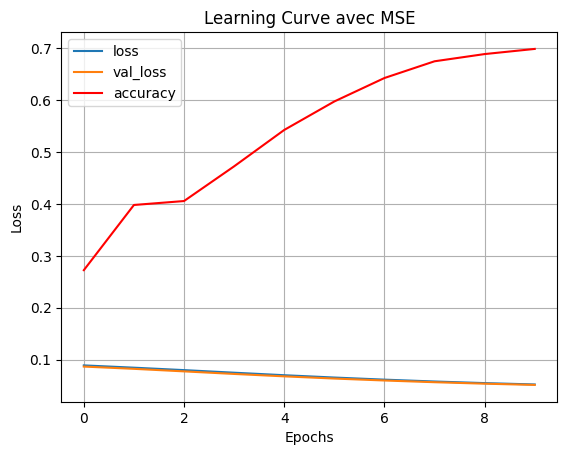

In [990]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec MSE")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

In [991]:
# accuracy: 0.5480 - loss: 0.0717 - val_accuracy: 0.5903 - val_loss: 0.0682

In [992]:
3/5

0.6

# MSE VS Cross-entropy ou Log loss

In [993]:
def mse(target, prediction):
  loss = (prediction-target) ** 2
  return loss

In [994]:
def log_loss(target, prediction):
  loss = - 1* np.log(prediction)
  return loss

In [995]:
prediction = np.arange(0, 1, 0.01)
prediction

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [996]:
target = np.ones_like(prediction)
target

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [997]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

/tmp/ipython-input-4183768036.py:2: RuntimeWarning: divide by zero encountered in log
  loss = - 1* np.log(prediction)


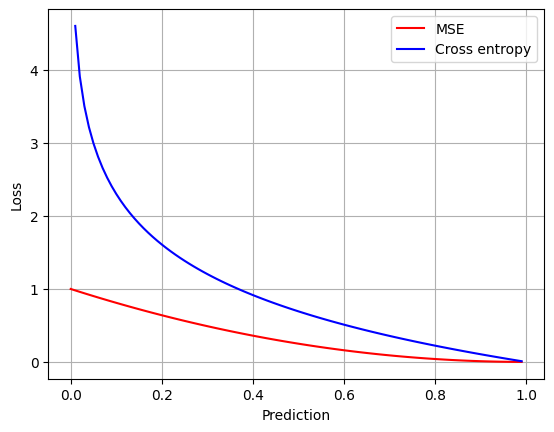

In [998]:
plt.plot(prediction, loss_mse, c='r', label='MSE')
plt.plot(prediction, loss_ce, c='b', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [999]:
def log_loss(target, prediction):
  loss = - 1* np.log(1-prediction)
  return loss

In [1000]:
np.zeros_like

<function zeros_like at 0x7ab9f913b6f0>

In [1001]:
target = np.zeros_like(prediction)
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [1002]:
loss_mse = mse(target, prediction)
loss_ce = log_loss(target, prediction)

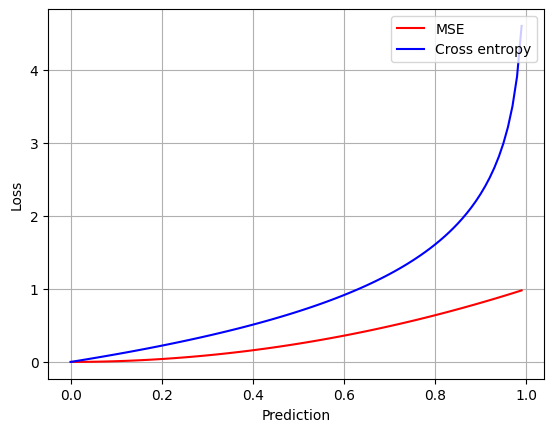

In [1003]:
plt.plot(prediction, loss_mse, c='red', label='MSE')
plt.plot(prediction, loss_ce, c='blue', label="Cross entropy")
plt.xlabel("Prediction")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

# Entrainement avec cross entropy comme Loss

In [1004]:
model = Sequential([ Dense(units=784, activation="sigmoid"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5675 - loss: 1.4992 - val_accuracy: 0.7439 - val_loss: 0.7848
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7570 - loss: 0.7317 - val_accuracy: 0.7727 - val_loss: 0.6633
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7794 - loss: 0.6373 - val_accuracy: 0.7874 - val_loss: 0.6080
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7958 - loss: 0.5872 - val_accuracy: 0.7979 - val_loss: 0.5740
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8059 - loss: 0.5524 - val_accuracy: 0.8054 - val_loss: 0.5525
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8192 - loss: 0.5237 - val_accuracy: 0.8042 - val_loss: 0.5438
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8219 - loss: 0.5092 - val_accuracy: 0.8151 - val_loss: 0.5233
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8300 - loss: 0

In [1005]:
histos['CROSS ENTROPY']=h

# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202

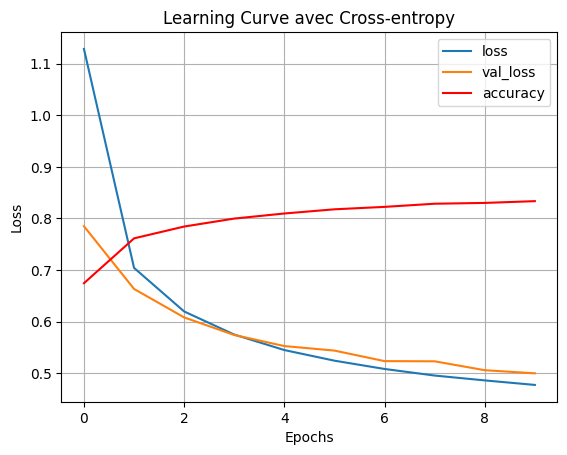

In [1006]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Nouvelle fonction d'activation : Relu (REctified Linear Unit)

In [1007]:
values = np.arange(-5, 5, 0.1)

In [1008]:
sig = tf.nn.sigmoid(values)

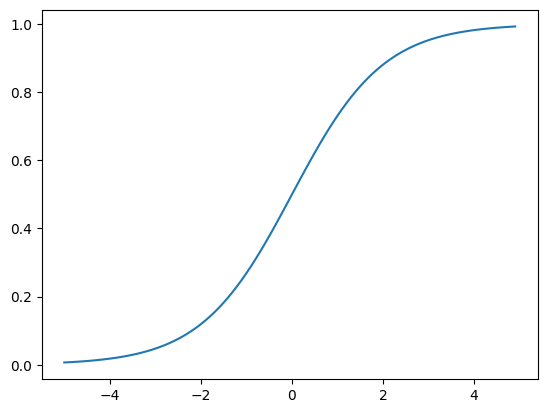

In [1009]:
plt.plot(values, sig)
plt.show()

In [1010]:
def relu(vect):
  return np.maximum(0, vect)

In [1011]:
relu_values = relu(values)

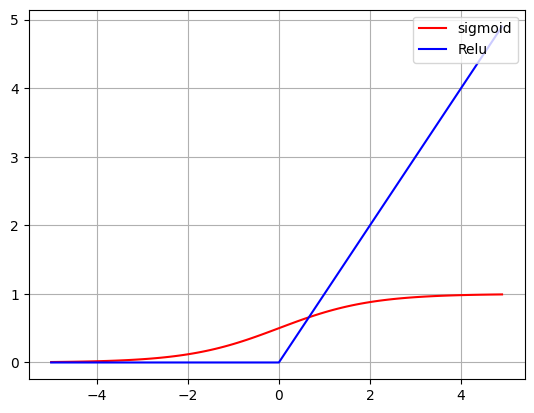

In [1012]:
plt.plot(values, sig, c='r', label="sigmoid")
plt.plot(values, relu_values, c='b', label="Relu")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [1013]:
model = Sequential([ Dense(units=784, activation="relu"),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7098 - loss: 0.9374 - val_accuracy: 0.8139 - val_loss: 0.5499
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8279 - loss: 0.5077 - val_accuracy: 0.8305 - val_loss: 0.4926
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8413 - loss: 0.4593 - val_accuracy: 0.8396 - val_loss: 0.4670
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8515 - loss: 0.4298 - val_accuracy: 0.8377 - val_loss: 0.4575
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8592 - loss: 0.4119 - val_accuracy: 0.8460 - val_loss: 0.4355
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8654 - loss: 0.3925 - val_accuracy: 0.8495 - val_loss: 0.4258
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8651 - loss: 0.3888 - val_accuracy: 0.8444 - val_loss: 0.4402
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8683 - loss: 0

In [1014]:
histos['relu']=h
# Epoch 5/5
# MSE           : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu          : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453

# Epoch 50/50
# MSE           : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu          : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137

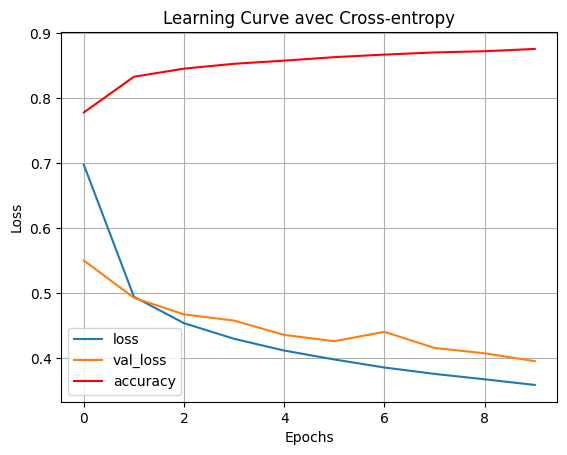

In [1015]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec Cross-entropy")
  plt.legend()
  plt.grid()
  plt.show()

plot_learning_curve(h.history)

# Réseau de neurones plus complexe

In [1016]:
model.summary()

Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_172 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (32, 10)               │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,292 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [1017]:
model = Sequential([ Dense(units=784, activation="relu"),
                     Dense(units=128, activation="relu"),
                     Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7184 - loss: 0.9051 - val_accuracy: 0.8244 - val_loss: 0.5113
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8339 - loss: 0.4805 - val_accuracy: 0.8388 - val_loss: 0.4637
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8523 - loss: 0.4246 - val_accuracy: 0.8450 - val_loss: 0.4354
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8578 - loss: 0.4022 - val_accuracy: 0.8494 - val_loss: 0.4212
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8681 - loss: 0.3770 - val_accuracy: 0.8520 - val_loss: 0.4109
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8722 - loss: 0.3620 - val_accuracy: 0.8615 - val_loss: 0.3910
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8790 - loss: 0.3422 - val_accuracy: 0.8626 - val_loss: 0.3878
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8791 - loss:

In [1018]:
histos['complexe']=h
# Epoch 5/5
# MSE            : accuracy: 0.5523 - loss: 0.0708 - val_accuracy: 0.5839 - val_loss: 0.0674
# CROSS ENTROPY  : accuracy: 0.8085 - loss: 0.5455 - val_accuracy: 0.8037 - val_loss: 0.5520
# relu           : accuracy: 0.8570 - loss: 0.4169 - val_accuracy: 0.8406 - val_loss: 0.4453
# model complexe : accuracy: 0.8676 - loss: 0.3768 - val_accuracy: 0.8541 - val_loss: 0.4082

# Epoch 50/50
# MSE            : accuracy: 0.7930 - loss: 0.0310 - val_accuracy: 0.7834 - val_loss: 0.0319
# CROSS ENTROPY  : accuracy: 0.8674 - loss: 0.3769 - val_accuracy: 0.8482 - val_loss: 0.4202
# relu           : accuracy: 0.9247 - loss: 0.2136 - val_accuracy: 0.8892 - val_loss: 0.3137
# model complexe :

In [1019]:
model.summary()

Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_174 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [1020]:
import matplotlib.pyplot as plt

def plot_loss_curve(history):


  plt.plot(list(range(len(history['loss']))), history['loss'], label = "loss")
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label="val_loss")
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Loss Curve")
  plt.legend(loc='upper right')
  plt.show()

def plot_accuracy_curve(history):


  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label = "accuracy")
  plt.plot(list(range(len(history['val_accuracy']))), history['val_accuracy'], label="val_accuracy")
  plt.xlabel('Epochs')
  plt.ylabel("accuracy")
  plt.title("Accuracy Curve")
  plt.legend(loc='upper right')
  plt.show()


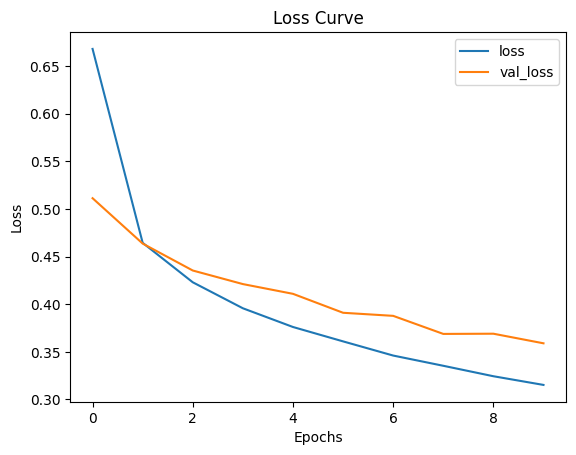

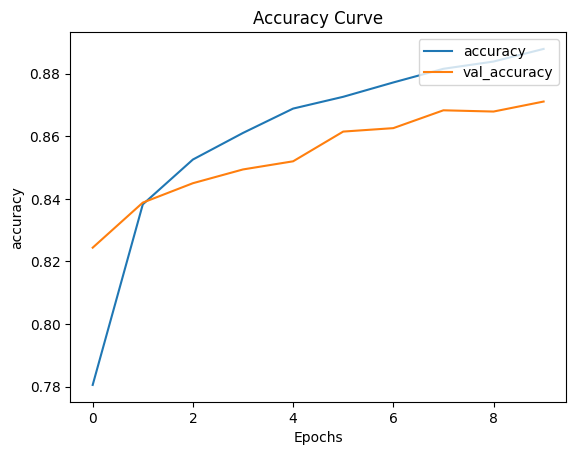

In [1021]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Combattre le overfitting : Dropout

In [1022]:
dropout = tf.keras.layers.Dropout(0.5, input_shape=(2,))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [1023]:
# ?tf.keras.layers.Dropout

In [1024]:
x = np.arange(1,11).reshape(5, 2).astype(np.float32)

In [1025]:
x

array([[ 1.,  2.],
       [ 3.,  4.],
       [ 5.,  6.],
       [ 7.,  8.],
       [ 9., 10.]], dtype=float32)

In [1026]:
dropout(x, training=True)

<tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 2.,  4.],
       [ 6.,  0.],
       [ 0., 12.],
       [14., 16.],
       [ 0.,  0.]], dtype=float32)>

In [1027]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))
# default: epochs=50

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.5984 - loss: 1.1620 - val_accuracy: 0.8069 - val_loss: 0.5615
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7917 - loss: 0.6041 - val_accuracy: 0.8271 - val_loss: 0.4898
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8159 - loss: 0.5286 - val_accuracy: 0.8360 - val_loss: 0.4554
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8301 - loss: 0.4870 - val_accuracy: 0.8415 - val_loss: 0.4342
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8389 - loss: 0.4591 - val_accuracy: 0.8493 - val_loss: 0.4164
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8485 - loss: 0.4301 - val_accuracy: 0.8517 - val_loss: 0.4046
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8487 - loss: 0.4227 - val_accuracy: 0.8561 - val_loss: 0.3947
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8528 - loss: 0

In [1028]:
histos['Dropout']=h

# Cf bilan en fin de doc

In [1029]:
model.summary()

Model: "sequential_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_177 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_178 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_179 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

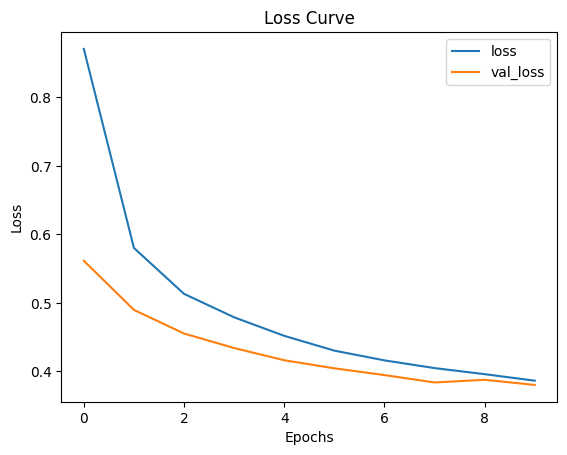

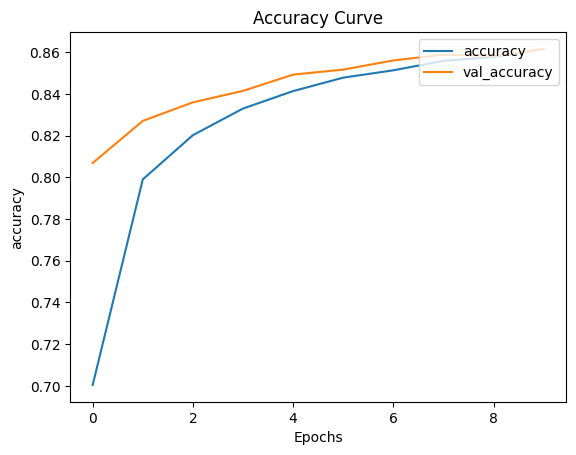

In [1030]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

# Adam optimiser

In [1031]:
adam = tf.keras.optimizers.Adam(
    learning_rate=0.01,
    beta_1=0.9,
    beta_2=0.999)

In [1032]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=adam, metrics=["accuracy"])
h = model.fit(a_training_images, training_labels, epochs=nb_epochs, validation_data=(a_test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.6068 - loss: 1.1866 - val_accuracy: 0.7522 - val_loss: 0.6924
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.6591 - loss: 0.9393 - val_accuracy: 0.7470 - val_loss: 0.7109
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.6609 - loss: 0.9355 - val_accuracy: 0.7367 - val_loss: 0.7047
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.6609 - loss: 0.9255 - val_accuracy: 0.7183 - val_loss: 0.6699
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.6776 - loss: 0.9070 - val_accuracy: 0.7047 - val_loss: 0.7033
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.6651 - loss: 0.9418 - val_accuracy: 0.7449 - val_loss: 0.6803
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.6756 - loss: 0.8910 - val_accuracy: 0.7652 - val_loss: 0.6791
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.6843 -

In [1033]:
histos['Adam'] = h

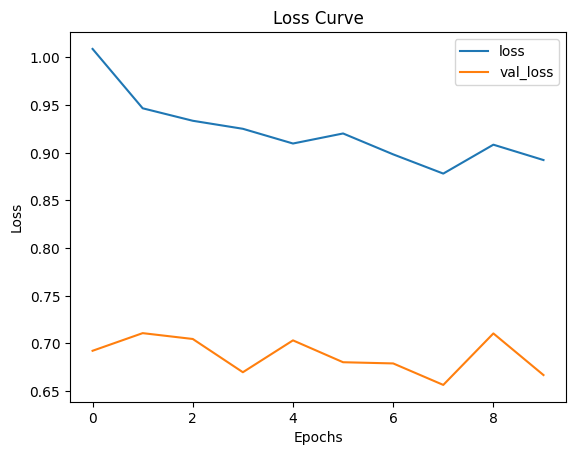

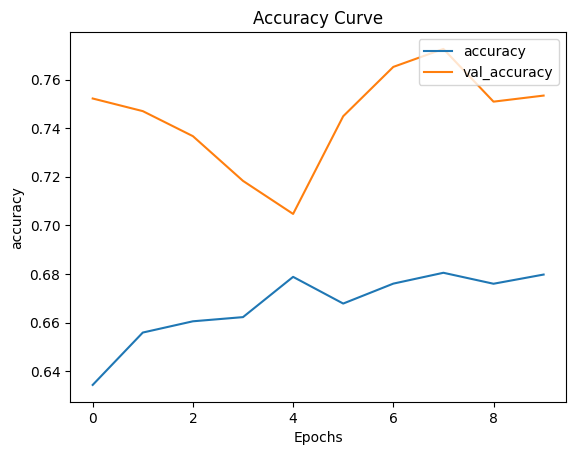

In [1034]:
plot_loss_curve(h.history)
plot_accuracy_curve(h.history)

In [1035]:
model.summary()

Model: "sequential_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_180 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_181 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_182 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,151,632 (8.21 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,434,422 (5.47 MB)

# Model Checkpoint

In [1036]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [1037]:
best_model = "best_model.h5"

model_ckp = ModelCheckpoint(filepath=best_model,
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)

In [1038]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=nb_epochs,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp])
# default: epochs=50

Epoch 1/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6025 - loss: 1.1484

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6026 - loss: 1.1481 - val_accuracy: 0.8064 - val_loss: 0.5525
Epoch 2/10
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7928 - loss: 0.5952

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7928 - loss: 0.5951 - val_accuracy: 0.8269 - val_loss: 0.4839
Epoch 3/10
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8217 - loss: 0.5178

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8217 - loss: 0.5178 - val_accuracy: 0.8384 - val_loss: 0.4476
Epoch 4/10
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8334 - loss: 0.4735

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8334 - loss: 0.4735 - val_accuracy: 0.8403 - val_loss: 0.4376
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8388 - loss: 0.4569

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8388 - loss: 0.4569 - val_accuracy: 0.8492 - val_loss: 0.4167
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8468 - loss: 0.4368

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8468 - loss: 0.4368 - val_accuracy: 0.8534 - val_loss: 0.4048
Epoch 7/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8513 - loss: 0.4232

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8513 - loss: 0.4232 - val_accuracy: 0.8574 - val_loss: 0.3945
Epoch 8/10
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8578 - loss: 0.4035

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8578 - loss: 0.4035 - val_accuracy: 0.8609 - val_loss: 0.3871
Epoch 9/10
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8598 - loss: 0.3970

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8598 - loss: 0.3970 - val_accuracy: 0.8627 - val_loss: 0.3773
Epoch 10/10
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8629 - loss: 0.3878

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8629 - loss: 0.3878 - val_accuracy: 0.8639 - val_loss: 0.3748


In [1039]:
model_save = tf.keras.models.load_model('best_model.h5')

In [1040]:
model_save.evaluate(a_test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8698 - loss: 0.3729


[0.3748414218425751, 0.8639000058174133]

# Early Stopping

In [1041]:
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2)

In [1042]:
model_ckp

In [1043]:
model = Sequential([ Dense(units=784, activation="relu"),
                    tf.keras.layers.Dropout(0.5),
                    Dense(units=128, activation="relu"),
                     tf.keras.layers.Dropout(0.3),
                   Dense(units=10, activation="softmax"),
                ])
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=["accuracy"])
h = model.fit(a_training_images, training_labels,
              epochs=nb_epochs,
              validation_data=(a_test_images, test_labels),
              callbacks =[model_ckp, stop])
# default: epochs=1000

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.6151 - loss: 1.1149 - val_accuracy: 0.8076 - val_loss: 0.5514
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.7959 - loss: 0.5869 - val_accuracy: 0.8293 - val_loss: 0.4822
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8193 - loss: 0.5131 - val_accuracy: 0.8383 - val_loss: 0.4503
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8312 - loss: 0.4778 - val_accuracy: 0.8435 - val_loss: 0.4315
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8404 - loss: 0.4509 - val_accuracy: 0.8491 - val_loss: 0.4179
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8461 - loss: 0.4350 - val_accuracy: 0.8551 - val_loss: 0.4035
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8524 - loss: 0.4211 - val_accuracy: 0.8550 - val_loss: 0.3995
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8576 - loss:

In [1044]:
arr=np.array([
      [1,2,3],
      [4,5,6]
    ])
print(arr)
arr.ndim

# type(h)
h.history['accuracy'][-1], h.history['loss'][-1]
histos['callbacks'] = h

[[1 2 3]
 [4 5 6]]


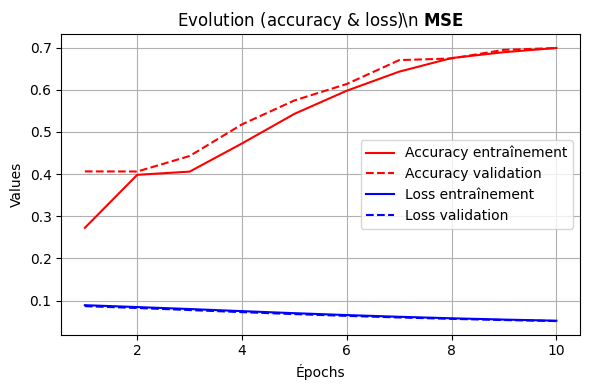

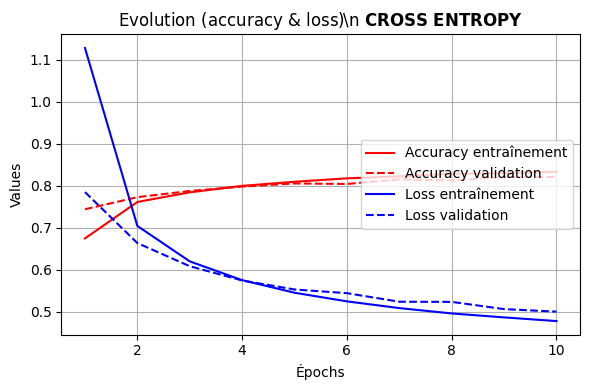

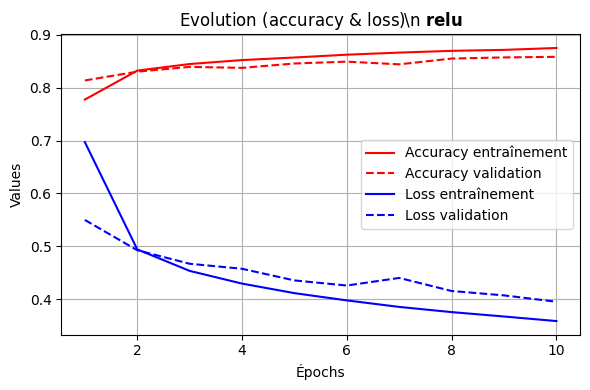

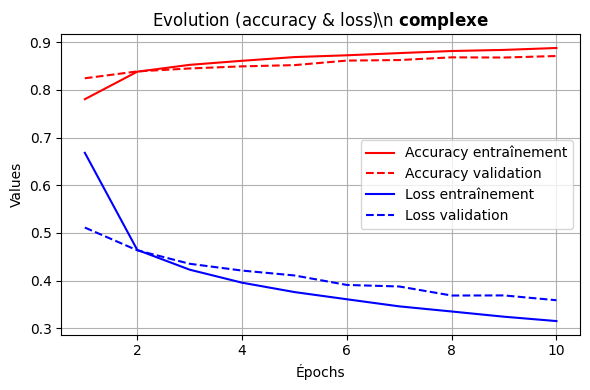

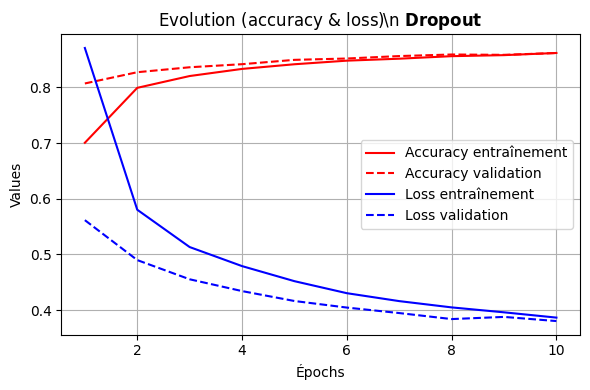

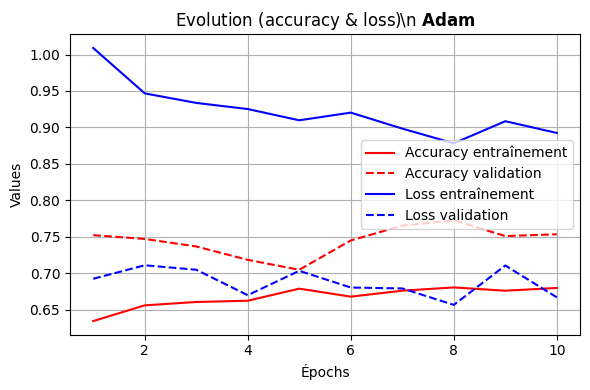

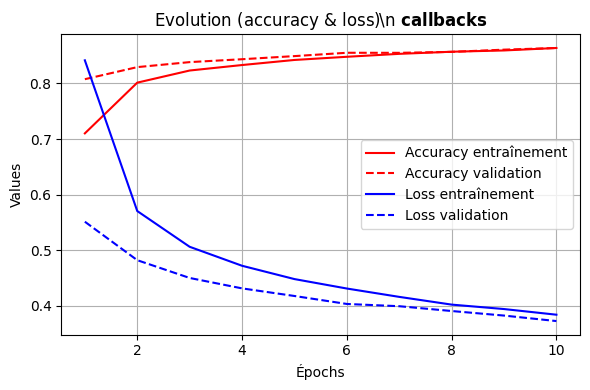

In [1045]:
import matplotlib.pyplot as plt

def graph4val(history, name='ok'):

    # Récupération des métriques
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Création de la figure
    plt.figure(figsize=(6, 4))

    # Accuracy
    plt.plot(epochs, acc, 'r-', label='Accuracy entraînement')
    plt.plot(epochs, val_acc, 'r--', label='Accuracy validation')

    # Loss
    plt.plot(epochs, loss, 'b-', label='Loss entraînement')
    plt.plot(epochs, val_loss, 'b--', label='Loss validation')

    # Mise en forme
    name = name.replace(" ", r"\ ")
    plt.title(rf"Evolution (accuracy & loss)\n $\mathbf{{{name}}}$")
    plt.xlabel("Épochs")
    plt.ylabel("Values")
    plt.legend(loc="center right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



modes = ['MSE', 'CROSS ENTROPY', 'relu', 'complexe', 'Dropout', 'Adam','callbacks']
for mode in modes:
  graph4val(histos[mode], mode)

## Voici les 4 courbes clés pour suivre l’apprentissage de ton modèle : accuracy et loss sur entraînement et validation.

Tu peux maintenant visualiser clairement :

* Si ton modèle progresse (accuracy monte, loss descend),

* S’il généralise bien (val_accuracy proche de accuracy),

* Ou s’il sur-apprend (val_loss qui remonte alors que loss descend).

## 📊 Lecture des courbes

* Courbes rouges : accuracy (entraînement et validation)

* Courbes bleues : loss (entraînement et validation)

* Si les courbes de validation divergent de celles d’entraînement, c’est un signal d’overfitting.

* Si les 4 courbes convergent bien, ton modèle est stable et performant.

In [1063]:
import pandas as pd

# Initialiser une liste pour stocker les résultats
results = []

for mode in modes:
    h = histos[mode].history
    results.append({
        'Méthode': mode,
        'Accuracy': h['accuracy'][-1],
        'Val Accuracy': h['val_accuracy'][-1],
        'Loss': h['loss'][-1],
        'Val Loss': h['val_loss'][-1]
    })

# Créer le DataFrame
df = pd.DataFrame(results)
df

,Méthode,Accuracy,Val Accuracy,Loss,Val Loss
0,MSE,0.698850,0.6988,0.052129,0.051242
1,CROSS ENTROPY,0.833417,0.8209,0.477221,0.499714
2,relu,0.875333,0.8586,0.358571,0.395147
3,complexe,0.887917,0.8711,0.315276,0.358975
4,Dropout,0.861633,0.8616,0.386555,0.380347
5,Adam,0.679750,0.7534,0.892398,0.666898
6,callbacks,0.863700,0.8637,0.384206,0.372770


In [1066]:
# Pour accuracy et val_accuracy → max
best_acc_idx = df['Accuracy'].idxmax()
best_val_acc_idx = df['Val Accuracy'].idxmax()

best_acc = df.loc[best_acc_idx, 'Méthode']
best_val_acc = df.loc[best_val_acc_idx, 'Méthode']

score_acc = df.loc[best_acc_idx, 'Accuracy']
score_val_acc = df.loc[best_val_acc_idx, 'Val Accuracy']

# Pour loss et val_loss → min
best_loss_idx = df['Loss'].idxmin()
best_val_loss_idx = df['Val Loss'].idxmin()

best_loss = df.loc[best_loss_idx, 'Méthode']
best_val_loss = df.loc[best_val_loss_idx, 'Méthode']

score_loss = df.loc[best_loss_idx, 'Loss']
score_val_loss = df.loc[best_val_loss_idx, 'Val Loss']

# Résumé sous forme de tableau
summary = pd.DataFrame({
    'Métrique': ['Accuracy', 'Val Accuracy', 'Loss', 'Val Loss'],
    'Meilleure Méthode': [best_acc, best_val_acc, best_loss, best_val_loss],
    'Meilleur Score': [score_acc, score_val_acc, score_loss, score_val_loss]
})

print(summary)

       Métrique Meilleure Méthode  Meilleur Score
0      Accuracy          complexe        0.887917
1  Val Accuracy          complexe        0.871100
2          Loss               MSE        0.052129
3      Val Loss               MSE        0.051242


# Predictions

In [1048]:
model_save = tf.keras.models.load_model('best_model.h5')

In [1049]:
model_save.summary()

Model: "sequential_70"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_183 (Dense)               │ (32, 784)              │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_185 (Dense)               │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,212 (2.74 MB)

 Trainable params: 717,210 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [1050]:
a_test_images[0].shape

(784,)

In [1051]:
test_labels[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [1052]:
np.argmax(test_labels[0])

np.int64(9)

In [1053]:
labels[9]

'ankle boot'

In [1054]:
pred = model_save.predict(a_test_images[9].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [1055]:
pred

array([[3.6810470e-05, 2.8511793e-05, 1.1748672e-05, 3.6264810e-05,
        5.9424724e-06, 5.0613387e-03, 6.0613070e-06, 9.9343079e-01,
        5.3256250e-04, 8.5011579e-04]], dtype=float32)

In [1056]:
np.argmax(pred)

np.int64(7)

In [1057]:
labels[7]

'sneaker'

In [1058]:
pred = model.predict(a_test_images[9].reshape((1, 784)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


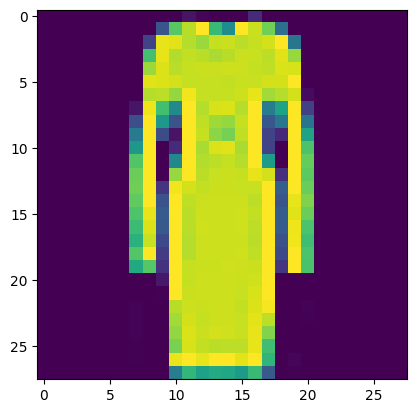

In [1059]:
import matplotlib.pyplot as plt
plt.imshow(training_images[2500])
# plt.title(labels[training_labels[45]])
plt.show()

In [1060]:
# (60000, 784) (1, 784)

## Epoch 5/5

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.5523   | 0.0708 | 0.5839       | 0.0674   |
| CROSS ENTROPY | 0.8085   | 0.5455 | 0.8037       | 0.5520   |
| relu          | 0.8570   | 0.4169 | 0.8406       | 0.4453   |
| model complexe| 0.8676   | 0.3768 | 0.8541       | 0.4082   |
| Dropout       | 0.8405   | 0.4501 | 0.8492       | 0.4157   |
| Adam          | 0.6805   | 0.8744 | 0.7445       | 0.6483   |
| Callbacks     | 0.8400   | 0.4521 | 0.8515       | 0.4164   |

## Epoch 50/50

| Model         | Accuracy | Loss   | Val Accuracy | Val Loss |
|---------------|----------|--------|--------------|----------|
| MSE           | 0.7930   | 0.0310 | 0.7834       | 0.0319   |
| CROSS ENTROPY | 0.8674   | 0.3769 | 0.8482       | 0.4202   |
| relu          | 0.9247   | 0.2136 | 0.8892       | 0.3137   |
| model complexe| 0.9536   | 0.1322 | 0.8966       | 0.3154   |
| Dropout       | 0.9107   | 0.2454 | 0.8954       | 0.3021   |
| Adam          | 0.6543   | 0.9675 | 0.7221       | 0.7787   |
| Callbacks     | 0.8815   | 0.3273 | 0.8764       | 0.3416   |

(Callbacks s'est arrêté à 20/50)